Assignment 1 
Game Data Predictor


In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, balanced_accuracy_score, precision_score, recall_score, f1_score, accuracy_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, RandomForestRegressor, AdaBoostRegressor, StackingClassifier, StackingRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor

In [89]:
## load game in as a dataframe
game_df = pd.read_csv("GameData.csv")

## print shape to find dimension
print(game_df.shape)

## find the features with missing values and show the count of how many there are
missing = game_df.isna().sum()
print(missing[missing > 0].sort_values(ascending=True))

(398, 470)
Play                   1
Math                   2
AdvantageP1            7
Balance                7
Drawishness            7
OutcomeUniformity    395
dtype: int64


In [90]:
print(game_df["Play"])
## the entire column is all 1's, no need for imputation we can just drop this column
game_df = game_df.drop(columns=["Play"])

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
393    1.0
394    1.0
395    1.0
396    1.0
397    1.0
Name: Play, Length: 398, dtype: float64


After looking through the CSV file, "Play" is a feature with all 1's and can be dropped

"Math"  is a qualitative feature and will require most frequent imputation

"AdvantageP1" is a quantitative feature and will require mean value imputation

"Balance"  is a quantitative feature and will require mean value imputation

"Drawishness" is a quantitative feature and will require mean value imputation

"Outcome Uniformity" has 395 missing values, out of 398 instances, this feature can be dropped.

The first column with only the game names can also be dropped, this categorical feature will have no impact on our model.

In [91]:
## drop gamename and outcome uniformity from dataframe
game_df = game_df.drop(columns=["GameName", "OutcomeUniformity"])

In [92]:
##imputation for PCA and cluster identification
##initialise simple imputer for categorical value
impfreq = SimpleImputer(strategy = "most_frequent")

##impute on "Math" feature
game_df[["Math"]] = impfreq.fit_transform(game_df[["Math"]])

##initialise simple imputer for numerical values
impmean = SimpleImputer(strategy = "mean")

##impute mean for the rest of the dataset
game_df[["AdvantageP1", "Balance", "Drawishness"]] = impmean.fit_transform(game_df[["AdvantageP1", "Balance", "Drawishness"]] )

##sanity check
missing = game_df.isna().sum()
print(missing[missing > 0].sort_values(ascending=True))

Series([], dtype: int64)


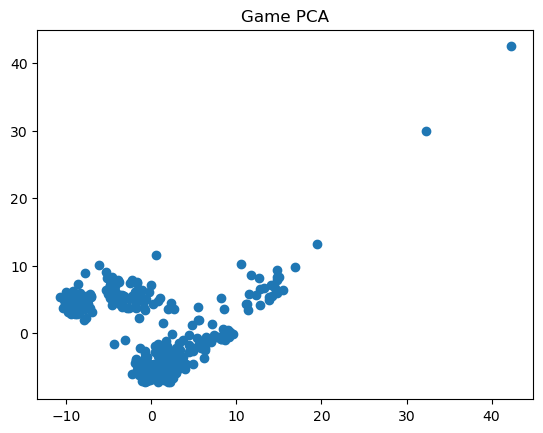

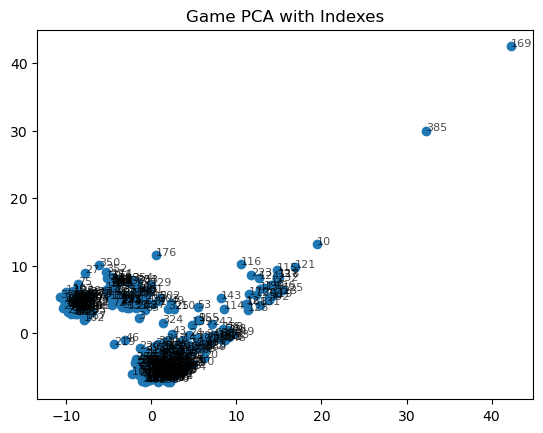

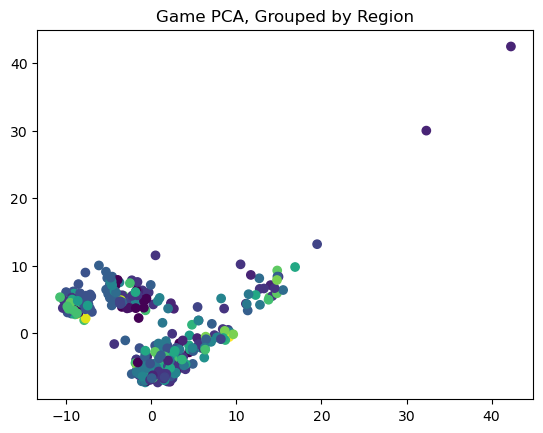

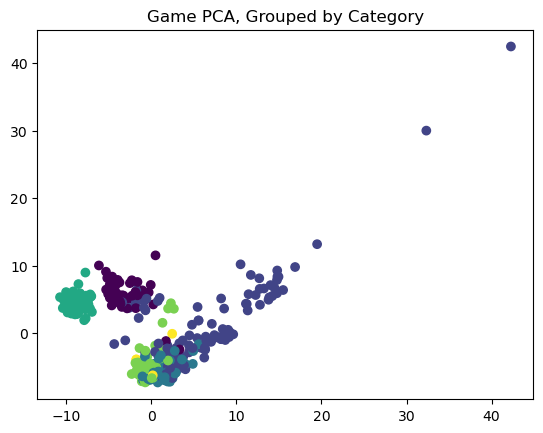

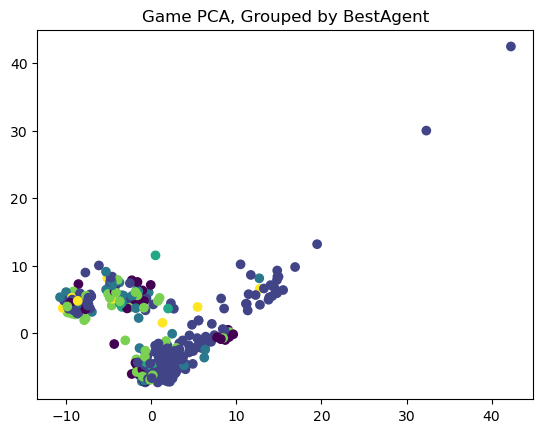

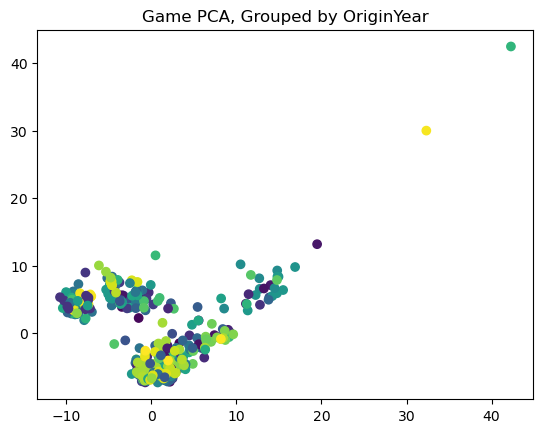

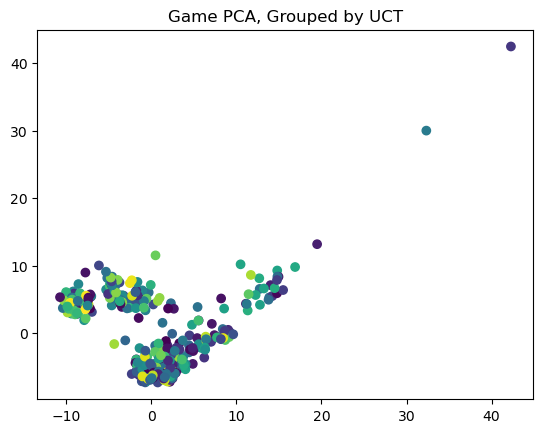

In [93]:
## scale the data
game_df_data = game_df.drop(columns= ["Category", "Region", "OriginYear", "BestAgent", "UCT"], axis=1)
game_scaled = StandardScaler().fit_transform(game_df_data)

## initialise and fit PCA to scaled game data
game_PCA = PCA().fit_transform(game_scaled)

## PCA scattter plot
plot = plt.scatter(game_PCA[:,0], game_PCA[:,1])
plt.title("Game PCA")
plt.show()

## scatter plot with row indexes on points
plot = plt.scatter(game_PCA[:,0], game_PCA[:,1])
for i in range(len(game_PCA)):
    plt.annotate(str(i), (game_PCA[i,0], game_PCA[i,1]),
                 fontsize=8, alpha=0.7)
plt.title("Game PCA with Indexes")
plt.show()

## PCA scatter plot grouped by region
plot = plt.scatter(game_PCA[:,0], game_PCA[:,1], c=pd.factorize(game_df["Region"])[0])
plt.title("Game PCA, Grouped by Region")
plt.show()

##PCA scatterplot grouped by Category
plot = plt.scatter(game_PCA[:,0], game_PCA[:,1], c=pd.factorize(game_df["Category"])[0])
plt.title("Game PCA, Grouped by Category")
plt.show()

##PCA scatterplot grouped by BestAgent
plot = plt.scatter(game_PCA[:,0], game_PCA[:,1], c=pd.factorize(game_df["BestAgent"])[0])
plt.title("Game PCA, Grouped by BestAgent")
plt.show()

plot = plt.scatter(game_PCA[:,0], game_PCA[:,1], c=pd.factorize(game_df["OriginYear"])[0])
plt.title("Game PCA, Grouped by OriginYear")
plt.show()

plot = plt.scatter(game_PCA[:,0], game_PCA[:,1], c=pd.factorize(game_df["UCT"])[0])
plt.title("Game PCA, Grouped by UCT")
plt.show()

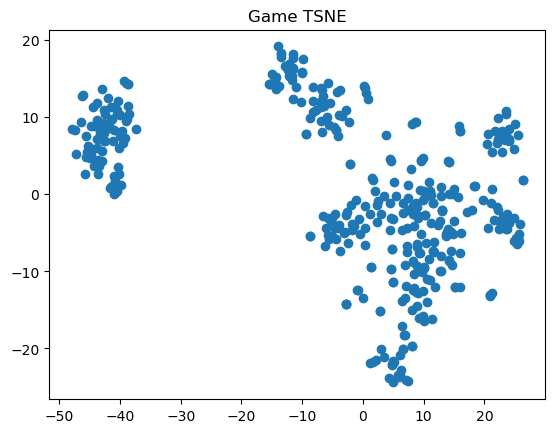

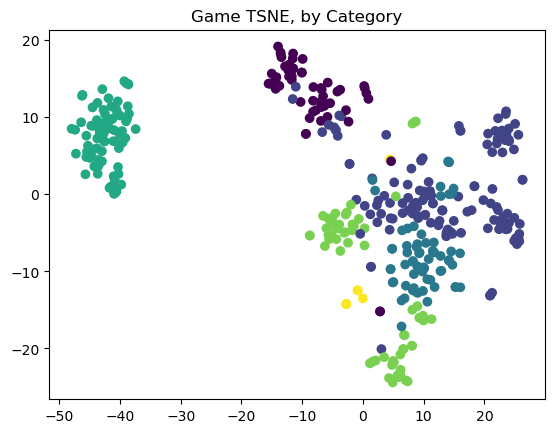

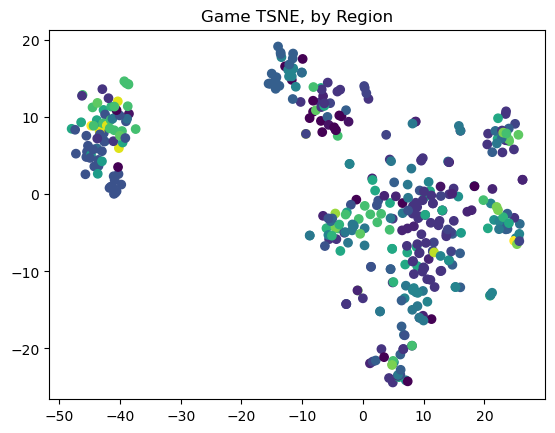

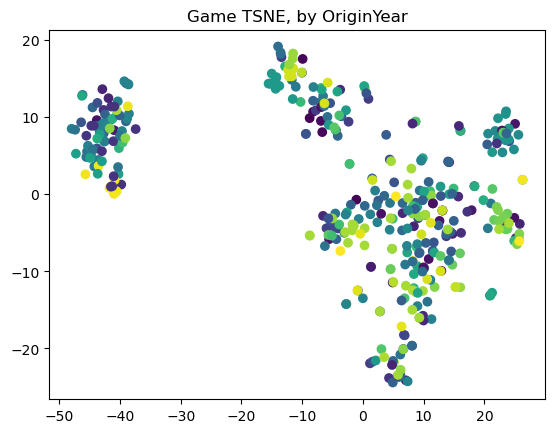

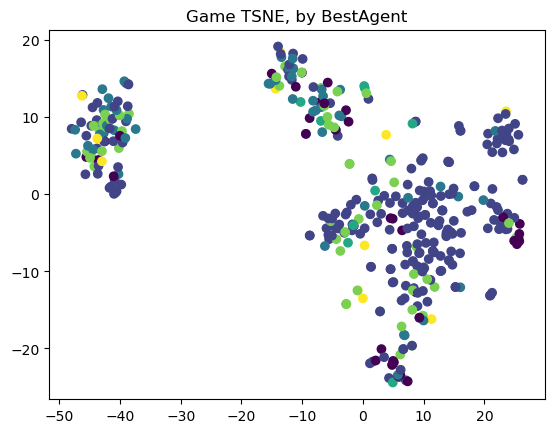

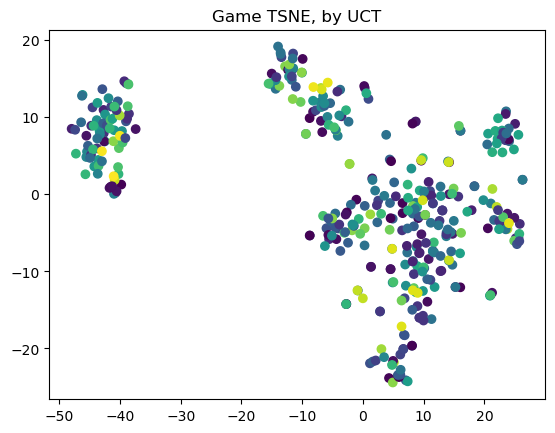

In [94]:
##initialise TSNE and fit onto scaled game data
game_TSNE = TSNE().fit_transform(game_scaled)

## TSNE scatter plot
plot = plt.scatter(game_TSNE[:,0], game_TSNE[:,1])
plt.title("Game TSNE")
plt.show()

## TSNE scatter plot by Category
plot = plt.scatter(game_TSNE[:,0], game_TSNE[:,1], c=pd.factorize(game_df["Category"])[0])
plt.title("Game TSNE, by Category")
plt.show()

## TSNE scatter plot by Region
plot = plt.scatter(game_TSNE[:,0], game_TSNE[:,1], c=pd.factorize(game_df["Region"])[0])
plt.title("Game TSNE, by Region")
plt.show()

## TSNE scatter plot by OriginYear
plot = plt.scatter(game_TSNE[:,0], game_TSNE[:,1], c=pd.factorize(game_df["OriginYear"])[0])
plt.title("Game TSNE, by OriginYear")
plt.show()

## TSNE scatter plot by BestAgent
plot = plt.scatter(game_TSNE[:,0], game_TSNE[:,1], c=pd.factorize(game_df["BestAgent"])[0])
plt.title("Game TSNE, by BestAgent")
plt.show()

## TSNE scatter plot by UCT
plot = plt.scatter(game_TSNE[:,0], game_TSNE[:,1], c=pd.factorize(game_df["UCT"])[0])
plt.title("Game TSNE, by UCT")
plt.show()


C:\Users\thoma\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\thoma\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\thoma\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\thoma\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

Text(0.5, 1.0, 'Elbow curve')

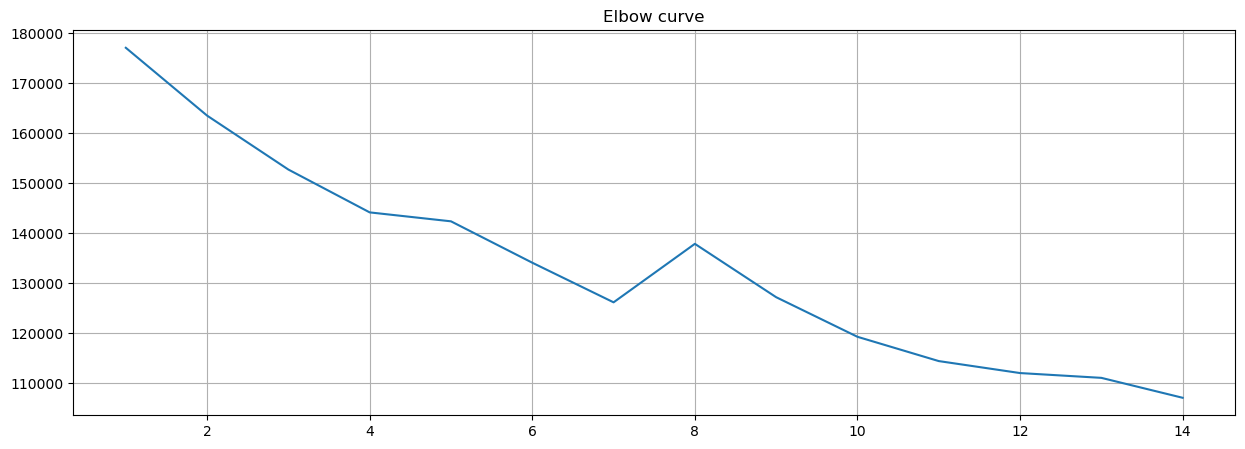

In [95]:
## k means clustering elbow curve
distortions = []
for k in range (1,15):
	kmeans= KMeans(n_clusters = k, random_state=42)
	kmeans.fit(game_scaled)
	distortions.append(kmeans.inertia_)

## plot the elbow curve
fig = plt.figure(figsize=(15,5))
plt.plot(range(1,15), distortions)
plt.grid(True)
plt.title('Elbow curve')


C:\Users\thoma\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\thoma\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\thoma\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\thoma\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

Text(0.5, 1.0, 'silhouette score')

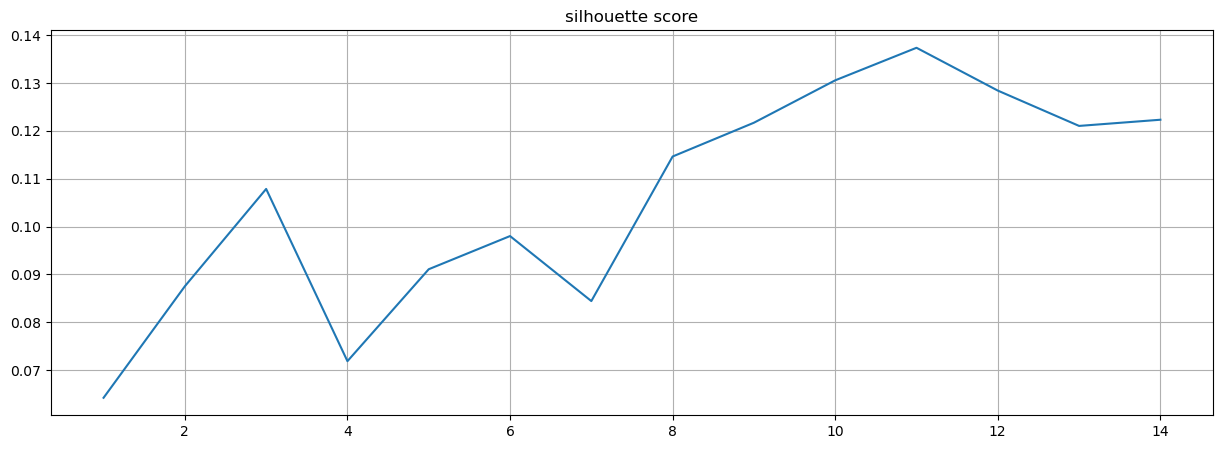

In [96]:
## silhouette score for clustering
silhouettes = []
for k in range (2,16):
	kmeans = KMeans(n_clusters=k, random_state=42)
	kmeans.fit(game_scaled)
	silhouettes.append(silhouette_score(game_scaled, kmeans.labels_))
	
fig = plt.figure(figsize=(15,5))
plt.plot(range(1,15), silhouettes)
plt.grid(True)
plt.title('silhouette score')

In [97]:
## drop the two rows that have outliers
game_df = game_df.drop(index=[169, 385])

##### The Following Blocks of code are all about preparing the data for model training and testing, this will include seperating the 5 targets and creating training, validation and testing sets, scaling the data, initialising the models, and setting up grid dictionaries ready for grid searches  

In [98]:
## reload the dataframe as imputation needs to be done now without the outliers and seperately for train test split
##repeating a few of the steps above
game_df2 = pd.read_csv("GameData.csv")
game_df2 = game_df2.drop(columns=["GameName", "OutcomeUniformity", "Play"])
game_df2 = game_df2.drop(index=[169, 385])

In [99]:
##initialise all models, ready for use in randomised search grids
KNNC = KNeighborsClassifier()
KNNR = KNeighborsRegressor()
LiR = LinearRegression()
ridge = Ridge()
lasso = Lasso()
elasticnet = ElasticNet()
LoR = LogisticRegression(random_state=42)
DTC = DecisionTreeClassifier(random_state=42)
DTR = DecisionTreeRegressor(random_state=42)
RFC = RandomForestClassifier(random_state=42)
RFR = RandomForestRegressor(random_state=42)
XGBC = xgb.XGBClassifier(eval_metric="logloss", random_state=42)
XGBR = xgb.XGBRegressor(random_state=42)
ADBR = AdaBoostRegressor(estimator=DTR, random_state=42)
ADBC = AdaBoostClassifier()
kfold5 = KFold(n_splits=5, shuffle=True, random_state=42)
kfold10 = KFold(n_splits=10, shuffle=True, random_state=42)
skfold3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
skfold5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skfold10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [100]:
##creating grids for randomised search or regular grid searches
## K-Nearest Neighbors Regression Grid
gridKNN = {'n_neighbors' : list(range(1,11)), 
           'metric' : ['euclidean', 'cosine', 'manhattan', 'minkowski'],
           'weights' : ['uniform', 'distance']}

## Logistic Regression Grid
gridLor = {'penalty' : ['l2'],
           'C' : [0.01, 0.1, 0.25, 0.5, 1, 10], 'solver' :  ['lbfgs', 'newton-cg'],
            }

gridLas = {'alpha' : [0.001, 0.01, 0.1, 0.25, 0.5, 1, 10, 100]}

gridRid = {'alpha' : [0.001, 0.01, 0.1, 0.25, 0.5, 1, 10, 100]}

gridEN = {'alpha': [0.001, 0.01, 0.1, 1, 10],'l1_ratio': [0.1, 0.5, 0.7, 0.9, 1]}
  

## Decision Tree Classifier and Regressor Grid 
gridDTC = {'criterion' : ['gini', 'entropy', 'log_loss'],
           'max_depth' : list(range(1, 25)),
           'min_samples_split' : [2,5,7,10],
           'min_samples_leaf' : [1, 2, 5, 7, 10],
           'max_features' : ['sqrt', 'log2']
          }

gridDTR = { 'criterion': ['squared_error', 'absolute_error'],
    'max_depth': [None] + list(range(5, 51, 5)), 
    'min_samples_split': [2, 5, 10, 20],           
    'min_samples_leaf': [1, 2, 5, 10],             
    'max_features': [None, 'sqrt', 'log2'] 
          }

gridRFC = {'n_estimators' : [100,200,500], 
           'criterion' : ['gini', 'entropy', 'log_loss'],
           'max_depth' : list(range(1,25)),
           'min_samples_split' : list(range(2,6)),
           'min_samples_leaf' : [1, 2, 5, 7, 10, 20, 25, 50],
           'max_features' : ['sqrt', 'log2', None]
          }

gridRFR = {'n_estimators' : [100,200,500], 
           'criterion' : ['squared_error', 'absolute_error'],
           'max_depth' : list(range(1, 51)),
           'min_samples_split' : list(range(2,10)),
           'min_samples_leaf' : [1, 2, 5, 7, 10, 20, 25, 50],
           'max_features' : ['sqrt', 'log2', None]
          }

gridXGB = {'n_estimators' : [200,500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0.5, 1, 1.5],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0],
            'max_depth': [3, 4, 5],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
           }


# CATEGORY

In [101]:
## see how frequent the types of instances the model will need to predict
category_counts = game_df["Category"].value_counts()
print(category_counts)

Category
War       128
Sow        75
Space      67
Hunt       63
Race       56
Puzzle      7
Name: count, dtype: int64


In [102]:
## create train test validation split for category model, first by splitting into combined training and validation and then performing a second split
X = game_df2.drop(columns= ["Category", "Region", "OriginYear", "BestAgent", "UCT"], axis=1)
Category_Y = game_df2.Category
X_trainval1, X_test1, y_trainval1, y_test1 = train_test_split(X, Category_Y, random_state=42, test_size=0.2, stratify=Category_Y) 
X_train1, X_val1, y_train1, y_val1 = train_test_split(X_trainval1, y_trainval1, random_state=42, test_size=0.25, stratify=y_trainval1)

##impute mean for Category split
X_train1[["AdvantageP1", "Balance", "Drawishness"]] = impmean.fit_transform(X_train1[["AdvantageP1", "Balance", "Drawishness"]] )
X_val1[["AdvantageP1", "Balance", "Drawishness"]] = impmean.transform(X_val1[["AdvantageP1", "Balance", "Drawishness"]] )
X_test1[["AdvantageP1", "Balance", "Drawishness"]] = impmean.transform(X_test1[["AdvantageP1", "Balance", "Drawishness"]] )

## impute most frequent
X_train1[["Math"]] = impfreq.fit_transform(X_train1[["Math"]])
X_val1[["Math"]] = impfreq.transform(X_val1[["Math"]])
X_test1[["Math"]] = impfreq.transform(X_test1[["Math"]])

## sanity check
print(X_train1.shape)
print(X_val1.shape)
print(X_test1.shape)

## scale train and test for Category
scaler1 = StandardScaler()
X_train1_scaled = scaler1.fit_transform(X_train1)
X_val1_scaled = scaler1.transform(X_val1)
X_test1_scaled = scaler1.transform(X_test1)

(237, 462)
(79, 462)
(80, 462)


### Grid Searches for Model Hyperparameters, testing against validation data

In [103]:
# k nearest neighbors grid search for target category -- note used grid search instead of randomised as only 100 possible iterations.
gsknn = GridSearchCV(KNNC, gridKNN, cv = skfold5, scoring = 'balanced_accuracy', n_jobs=-1)
gsknn.fit(X_train1_scaled, y_train1)
print(f"------- K Nearest Neighbors -------")
print("Accuracy best parameters", gsknn.best_params_)
print("Best model balanced accuracy on validation set:", balanced_accuracy_score(y_val1, gsknn.predict(X_val1_scaled)))

## logistic Regression grid search, stratified k fold - 5 folds, scoring on balanced accuracy
print("\n------- Logistic Regression -------")
gslor = GridSearchCV(LoR, gridLor, cv = skfold5, scoring = 'balanced_accuracy', n_jobs=-1)
gslor.fit(X_train1_scaled, y_train1)
print("Accuracy best parameters", gslor.best_params_)
print("Best model balanced accuracy on validation set:", balanced_accuracy_score(y_val1, gslor.predict(X_val1_scaled)))

## Decision tree Randomized search, stratified k fold - 5 folds, scoring on balanced accuracy
print("\n------- Decision Tree -------")
randacc = RandomizedSearchCV(DTC, gridDTC, cv = skfold5, n_iter=1000, scoring = 'balanced_accuracy', n_jobs=-1, random_state=42)
randacc.fit(X_train1, y_train1) ## decision tree does not need scaling
print("Accuracy best parameters", randacc.best_params_)
print("Best model balanced accuracy on validation set:", balanced_accuracy_score(y_val1, randacc.predict(X_val1)))

## Random Forest Randomized search, stratified k fold - 5 folds, scoring on balanced accuracy
print("\n------- Random Forest -------")
rsrf = RandomizedSearchCV(RFC, gridRFC, cv = skfold5, n_iter=10, scoring = 'balanced_accuracy', n_jobs=-1, random_state=42)
rsrf.fit(X_train1, y_train1) ## random forest does not need scaling
print("Accuracy best parameters", rsrf.best_params_)
print("Best model balanced accuracy on validation set:", balanced_accuracy_score(y_val1, rsrf.predict(X_val1)))

## to use xg boost target values need to be encoded
le1 = LabelEncoder()
y_trainval1_enc = le1.fit_transform(y_trainval1)
y_train1_enc = le1.transform(y_train1)
y_val1_enc = le1.transform(y_val1)
y_test1_enc = le1.transform(y_test1)

## XGBoost Randomized search, stratified k fold - 5 folds, scoring on balanced accuracy
print("\n------- XGBoost -------")
rsxg = RandomizedSearchCV(XGBC, gridXGB, cv = skfold5, n_iter=15, scoring = 'balanced_accuracy', n_jobs=-1, random_state=42)
rsxg.fit(X_train1_scaled, y_train1_enc)
print("Accuracy Best Parameters", rsxg.best_params_)
print("Best model balanced accuracy on validation set:", balanced_accuracy_score(y_val1_enc, rsxg.predict(X_val1_scaled)))


C:\Users\thoma\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.86595238 0.86595238 0.87001984 0.86595238 0.86373016 0.86595238
 0.83964286 0.87488095 0.77071429 0.87293651 0.80988095 0.88321429
 0.80599206 0.88126984 0.7768254  0.8768254  0.76849206 0.87710317
 0.77710317 0.84599206 0.92369048 0.92369048 0.94634921 0.92369048
 0.88234127 0.92206349 0.9065873  0.92845238 0.93738095 0.93678571
 0.94380952 0.94154762 0.93992063 0.93960317 0.93279762 0.94349206
 0.86672619 0.92876984 0.87224206 0.94349206        nan 0.92099206
        nan 0.92099206        nan 0.8744246         nan 0.8855754
        nan 0.87369048        nan 0.8431746         nan 0.87650794
        nan 0.84988095        nan 0.84988095        nan 0.85404762
 0.86595238 0.86595238 0.87001984 0.86595238 0.86373016 0.86595238
 0.83964286 0.87488095 0.77071429 0.87293651 0.80988095 0.88321429
 0.80599206 0.88126984 0.7768254  0.8768254  0.76849

------- K Nearest Neighbors -------
Accuracy best parameters {'metric': 'cosine', 'n_neighbors': 2, 'weights': 'uniform'}
Best model balanced accuracy on validation set: 0.9184149184149183

------- Logistic Regression -------
Accuracy best parameters {'C': 0.25, 'penalty': 'l2', 'solver': 'lbfgs'}
Best model balanced accuracy on validation set: 0.9032634032634034

------- Decision Tree -------
Accuracy best parameters {'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'criterion': 'entropy'}
Best model balanced accuracy on validation set: 0.8630536130536131

------- Random Forest -------
Accuracy best parameters {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 19, 'criterion': 'gini'}
Best model balanced accuracy on validation set: 0.956876456876457

------- XGBoost -------
Accuracy Best Parameters {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0

### Testing our best model hyperparameters against validation data on unseen test data

In [104]:
## testing best k nearest neighbors hyperparameters on additional holdout test set
print(f"------- K Nearest Neighbors -------")
knn1 = KNeighborsClassifier(n_neighbors = 2, metric = 'cosine', weights = 'uniform')
knn1.fit(X_train1_scaled, y_train1)
print("Accuracy score on holdout test set", knn1.score(X_test1_scaled, y_test1))
pred = knn1.predict(X_test1_scaled)
## compare results amongst 4 different scoring categories
print("Balanced Accuracy score on holdout test set", balanced_accuracy_score(y_test1, pred))
print("Precision score on holdout test set", precision_score(y_test1, pred, average = 'weighted'))
print("Recall Accuracy score on holdout test set", recall_score(y_test1, pred, average = 'weighted'))
print("F1 Accuracy score on holdout test set", f1_score(y_test1, pred, average = 'weighted'))

## testing best logistic regression hyperparameters on additional holdout test set
print("\n------- Logistic Regression -------")
logr1 = LogisticRegression(C=0.25, penalty = 'l2', solver = 'lbfgs')
logr1.fit(X_train1_scaled, y_train1)
print("Accuracy score on holdout test set", logr1.score(X_test1_scaled, y_test1))
pred = logr1.predict(X_test1_scaled)
## compare results amongst 4 different scoring categories
print("Balanced Accuracy score on holdout test set", balanced_accuracy_score(y_test1, pred))
print("Precision score on holdout test set", precision_score(y_test1, pred, average = 'weighted'))
print("Recall Accuracy score on holdout test set", recall_score(y_test1, pred, average = 'weighted'))
print("F1 Accuracy score on holdout test set", f1_score(y_test1, pred, average = 'weighted'))

## testing best decision tree hyper parameters on additional holdout test set
print("\n------- Decision Tree -------")
dtc1 = DecisionTreeClassifier(min_samples_split = 7, min_samples_leaf = 2, max_features = 'sqrt', max_depth = 20, criterion = 'entropy', random_state=42)
dtc1.fit(X_train1, y_train1)
print("Accuracy score on holdout test set", dtc1.score(X_test1, y_test1))
pred = dtc1.predict(X_test1)
## compare results amongst 4 different scoring categories
print("Balanced accuracy score on holdout test set", balanced_accuracy_score(y_test1, pred))
print("Precision score on holdout test set", precision_score(y_test1, pred, average = 'weighted'))
print("Recall Accuracy score on holdout test set", recall_score(y_test1, pred, average = 'weighted'))
print("F1 Accuracy score on holdout test set", f1_score(y_test1, pred, average = 'weighted'))

## testing adaboost against holdout test set
print("\n------- AdaBoost -------")
adb1 = AdaBoostClassifier()
adb1.fit(X_train1_scaled, y_train1)
print("Accuracy score on holdout test set", adb1.score(X_test1_scaled, y_test1))
pred = adb1.predict(X_test1_scaled)
## compare results amongst 4 different scoring categories
print("Balanced accuracy score on holdout test set", balanced_accuracy_score(y_test1, pred))
print("Precision score on holdout test set", precision_score(y_test1, pred, average = 'weighted'))
print("Recall Accuracy score on holdout test set", recall_score(y_test1, pred, average = 'weighted'))
print("F1 Accuracy score on holdout test set", f1_score(y_test1, pred, average = 'weighted'))

## testing best random forest hyperparameters against holdout test set
print("\n------- Random Forest -------")
rfc1 = RandomForestClassifier(n_estimators = 500, 
                             min_samples_split = 2, 
                             min_samples_leaf = 2, 
                             max_features = None, 
                             max_depth = 19, 
                             criterion = 'gini', 
                             random_state=42)
rfc1.fit(X_train1, y_train1)
print("Accuracy score on holdout test set", rfc1.score(X_test1, y_test1))
pred = rfc1.predict(X_test1)
## compare results amongst 4 different scoring categories
print("Balanced accuracy score on holdout test set", balanced_accuracy_score(y_test1, pred))
print("Precision score on holdout test set", precision_score(y_test1, pred, average = 'weighted'))
print("Recall Accuracy score on holdout test set", recall_score(y_test1, pred, average = 'weighted'))
print("F1 Accuracy score on holdout test set", f1_score(y_test1, pred, average = 'weighted'))

## testing best XGBoost hyperparameters on holdout test set
print("\n------- XGBoost -------")
xgbc1 = xgb.XGBClassifier(subsample = 0.8, 
                            n_estimators = 200, 
                            min_child_weight = 1,
                            max_depth = 3, 
                            learning_rate=0.2,
                            gamma = 0.5,
                            colsample_bytree = 1,
                            random_state=42)
xgbc1.fit(X_train1_scaled, y_train1_enc)
print("Accuracy score on holdout test set", xgbc1.score(X_test1_scaled, y_test1_enc))
pred = xgbc1.predict(X_test1_scaled)
## compare results amongst 4 different scoring categories
print("Balanced accuracy score on holdout test set", balanced_accuracy_score(y_test1_enc, pred))
print("Precision score on holdout test set", precision_score(y_test1_enc, pred, average = 'weighted'))
print("Recall Accuracy score on holdout test set", recall_score(y_test1_enc, pred, average = 'weighted'))
print("F1 Accuracy score on holdout test set", f1_score(y_test1_enc, pred, average = 'weighted'))


------- K Nearest Neighbors -------
Accuracy score on holdout test set 0.9
Balanced Accuracy score on holdout test set 0.9335664335664334
Precision score on holdout test set 0.9116771708683473
Recall Accuracy score on holdout test set 0.9
F1 Accuracy score on holdout test set 0.8999380385876611

------- Logistic Regression -------
Accuracy score on holdout test set 0.9625
Balanced Accuracy score on holdout test set 0.9656177156177156
Precision score on holdout test set 0.9642592592592593
Recall Accuracy score on holdout test set 0.9625
F1 Accuracy score on holdout test set 0.9625216717786659

------- Decision Tree -------
Accuracy score on holdout test set 0.8875
Balanced accuracy score on holdout test set 0.9143356643356643
Precision score on holdout test set 0.9160685805422648
Recall Accuracy score on holdout test set 0.8875
F1 Accuracy score on holdout test set 0.892978896103896

------- AdaBoost -------
Accuracy score on holdout test set 0.825
Balanced accuracy score on holdout tes

### Stacking Model Ensemble for all Category Models

In [105]:
## initialise our final stack model
stack_final_model1 = LogisticRegression(penalty = 'l2', solver = 'lbfgs', C = 0.25)

## create the stack containing all our best models
stack1 = StackingClassifier( estimators = [
    ('knn1', knn1),
    ('logr1', logr1),
    ('dtc', dtc1),
    ('rfc', rfc1),
    ('adb', adb1),
    ('xgbc1', xgbc1)],
    final_estimator = stack_final_model1,
    cv = skfold5
)

## fit the stack to the training data
stack1.fit(X_train1_scaled, y_train1)
pred = stack1.predict(X_test1_scaled)

## print the 5 scoring methods we have previously compared our testing to
print("Accuracy score for Stack Model ", accuracy_score(y_test1, pred))
print("Balanced Accuracy score for Stack Model ", balanced_accuracy_score(y_test1, pred))
print("Precision score for Stack Model ", precision_score(y_test1, pred, average='weighted'))
print("Recall score for Stack Model ", recall_score(y_test1, pred, average='weighted'))
print("F1 Score score for Stack Model ", f1_score(y_test1, pred, average='weighted'))

Accuracy score for Stack Model  0.9875
Balanced Accuracy score for Stack Model  0.9871794871794872
Precision score for Stack Model  0.9879629629629629
Recall score for Stack Model  0.9875
F1 Score score for Stack Model  0.987367924528302


# Region

In [106]:
## get a count of instances in target region
region_counts = game_df["Region"].value_counts()
print(region_counts)

Region
Southern Asia        82
Eastern Africa       41
Southern Europe      38
Northern Asia        32
Northern Europe      32
Western Africa       29
Southeastern Asia    27
Northern Africa      21
Eastern Asia         21
Northern America     19
Western Asia          9
Middle Africa         7
Eastern Europe        7
Central Asia          7
Western Europe        7
South America         5
Caribbean             4
Polynesia             3
Central America       2
Micronesia            2
Southern Africa       1
Name: count, dtype: int64


In [107]:
## create copy of game_df as some merges of categories will be made
game_df3 = game_df2.copy()

In [108]:
## merge low instance regions with another region similarly located
game_df3['Region'] = game_df3['Region'].replace('Southern Africa', 'Middle Africa')
game_df3['Region'] = game_df3['Region'].replace('Micronesia', 'Polynesia')
game_df3['Region'] = game_df3['Region'].replace('Caribbean', 'Central America')
region_counts = game_df3["Region"].value_counts()
print(region_counts)

Region
Southern Asia        82
Eastern Africa       41
Southern Europe      38
Northern Europe      32
Northern Asia        32
Western Africa       29
Southeastern Asia    27
Northern Africa      21
Eastern Asia         21
Northern America     19
Western Asia          9
Middle Africa         8
Eastern Europe        7
Central Asia          7
Western Europe        7
Central America       6
South America         5
Polynesia             5
Name: count, dtype: int64


In [109]:
## now for train test validation splitting
X = game_df3.drop(columns= ["Category", "Region", "OriginYear", "BestAgent", "UCT"], axis=1)
Region_Y = game_df3.Region
X_trainval2, X_test2, y_trainval2, y_test2 = train_test_split(X, Region_Y, random_state=42, test_size=0.2, stratify=Region_Y)
X_train2, X_val2, y_train2, y_val2 = train_test_split(X_trainval2, y_trainval2, random_state=42, test_size=0.25, stratify=y_trainval2)

##impute mean for Category split
X_train2[["AdvantageP1", "Balance", "Drawishness"]] = impmean.fit_transform(X_train2[["AdvantageP1", "Balance", "Drawishness"]] )
X_val2[["AdvantageP1", "Balance", "Drawishness"]] = impmean.transform(X_val2[["AdvantageP1", "Balance", "Drawishness"]] )
X_test2[["AdvantageP1", "Balance", "Drawishness"]] = impmean.transform(X_test2[["AdvantageP1", "Balance", "Drawishness"]] )

X_train2[["Math"]] = impfreq.fit_transform(X_train2[["Math"]])
X_val2[["Math"]] = impfreq.transform(X_val2[["Math"]])
X_test2[["Math"]] = impfreq.transform(X_test2[["Math"]])

##initialise target independent scaler
scaler2 = StandardScaler()

## scale train and test for Region
X_train2_scaled = scaler2.fit_transform(X_train2)
X_val2_scaled = scaler2.transform(X_val2)
X_test2_scaled = scaler2.transform(X_test2)

In [110]:
# KNN grid search search
rsknn = GridSearchCV(KNNC, gridKNN, cv=skfold3, scoring='balanced_accuracy', n_jobs=-1)
rsknn.fit(X_train2_scaled, y_train2)
print(f"------- K Nearest Neighbors -------")
print("Best parameters:", rsknn.best_params_)
pred = rsknn.predict(X_val2_scaled)
print("Balanced accuracy on validation set:", balanced_accuracy_score(y_val2, pred))

# Logistic Regression grid search
LoR2 = LogisticRegression(class_weight='balanced', random_state=42)
rslor = GridSearchCV(LoR2, gridLor, cv=skfold3, scoring='balanced_accuracy', n_jobs=-1)
rslor.fit(X_train2_scaled, y_train2)
print("\n------- Logistic Regression -------")
print("Best parameters:", rslor.best_params_)
pred = rslor.predict(X_val2_scaled)
print("Balanced accuracy on validation set:", balanced_accuracy_score(y_val2, pred))

# Decision Tree randomised search
randacc = RandomizedSearchCV(DTC, gridDTC, cv=skfold3, n_iter=1000, scoring='balanced_accuracy', n_jobs=-1, random_state=42)
randacc.fit(X_train2, y_train2)
print("\n------- Decision Tree -------")
print("Best parameters:", randacc.best_params_)
pred = randacc.predict(X_val2)
print("Balanced accuracy on validation set:", balanced_accuracy_score(y_val2, pred))

# Random Forest randmomized search
rsrf = RandomizedSearchCV(RFC, gridRFC, cv=skfold3, n_iter=20, scoring='balanced_accuracy', n_jobs=-1, random_state=42)
rsrf.fit(X_train2, y_train2)
print("\n------- Random Forest -------")
print("Best parameters:", rsrf.best_params_)
pred = rsrf.predict(X_val2)
print("Balanced accuracy on validation set:", balanced_accuracy_score(y_val2, pred))

# XGBoost (with encoded targets)
le2 = LabelEncoder()
y_trainval2_enc = le2.fit_transform(y_trainval2)
y_train2_enc = le2.transform(y_train2)
y_val2_enc = le2.transform(y_val2)
y_test2_enc = le2.transform(y_test2)

## randomized search for XGBoost
rsxg2 = RandomizedSearchCV(XGBC, gridXGB, cv=skfold3, n_iter=15, scoring='balanced_accuracy', n_jobs=-1, random_state=42)
rsxg2.fit(X_train2_scaled, y_train2_enc)
print("\n------- XGBoost -------")
print("Best parameters:", rsxg2.best_params_)
pred = rsxg2.predict(X_val2_scaled)
print("Balanced accuracy on validation set:", balanced_accuracy_score(y_val2_enc, pred))

C:\Users\thoma\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.23383736 0.23383736 0.21659253 0.23383736 0.2237261  0.20438777
 0.22199161 0.21064685 0.19188604 0.20549742 0.16802141 0.17582175
 0.17985809 0.17201884 0.15676505 0.16778798 0.14435129 0.16128445
 0.14539847 0.16121637 0.22407126 0.22407126 0.19476908 0.22407126
 0.22271026 0.22517356 0.20913152 0.22099025 0.18939638 0.22482039
 0.17196178 0.20639568 0.17280147 0.20495686 0.19272703 0.20656815
 0.19768735 0.21882759 0.16373673 0.21103806        nan 0.23408916
        nan 0.23408916        nan 0.22900565        nan 0.22609559
        nan 0.22528703        nan 0.23417345        nan 0.22339498
        nan 0.22133736        nan 0.21793322        nan 0.21469248
 0.23383736 0.23383736 0.21659253 0.23383736 0.2237261  0.20438777
 0.22199161 0.21064685 0.19188604 0.20549742 0.16802141 0.17582175
 0.17985809 0.17201884 0.15676505 0.16778798 0.1443

------- K Nearest Neighbors -------
Best parameters: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}
Balanced accuracy on validation set: 0.2164351851851852

------- Logistic Regression -------
Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Balanced accuracy on validation set: 0.2604166666666667

------- Decision Tree -------
Best parameters: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 18, 'criterion': 'gini'}
Balanced accuracy on validation set: 0.21203703703703702

------- Random Forest -------
Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 14, 'criterion': 'log_loss'}
Balanced accuracy on validation set: 0.3074074074074074

------- XGBoost -------
Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0.5, 'colsample_bytree': 1.0}
Balanced accuracy on validation s

In [111]:
## better way for displaying scores would be to create a loop with our models and their best hyperparameters
## create a models dictioniary to store our "best" models
models = {
    "KNN": KNeighborsClassifier(metric='manhattan', n_neighbors=6, weights='distance'),
    "Logistic Regression": LogisticRegression(C=0.1, penalty='l2', solver='lbfgs'),
    "Decision Tree": DecisionTreeClassifier(min_samples_split=2, min_samples_leaf=1, max_features='log2', max_depth=18, criterion='gini', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', max_depth=14, criterion='log_loss', random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, estimator = DTC, random_state=42)
}

## for loop for going through each 
for name, model in models.items():
    # choose scaled or unscaled 
    if name in ["KNN", "Logistic Regression"]:  
        model.fit(X_train2_scaled, y_train2)
        pred = model.predict(X_test2_scaled)
        acc = model.score(X_test2_scaled, y_test2)
    else:
        model.fit(X_train2, y_train2)
        pred = model.predict(X_test2)
        acc = model.score(X_test2, y_test2)

    print(f"\n------- {name} -------")
    print("Accuracy:", acc)
    print("Balanced accuracy score on holdout test set", balanced_accuracy_score(y_test2, pred))
    print("Precision score on holdout test set", precision_score(y_test2, pred, average='weighted', zero_division=0))
    print("Recall Score score on holdout test set", recall_score(y_test2, pred, average='weighted'))
    print("F1 Score score on holdout test set", f1_score(y_test2, pred, average='weighted'))

## use xgboost outside of loop as encoded values needed
print("\n------- XGBoost -------")
xgbc2 = xgb.XGBClassifier(subsample = 0.8, 
                            n_estimators = 200, 
                            min_child_weight = 1,
                            max_depth = 3,
                            learning_rate=0.2,
                            gamma = 0.5,
                            colsample_bytree = 1,
                            random_state=42)
xgbc2.fit(X_train2_scaled, y_train2_enc)
print("Accuracy score on holdout test set", xgbc2.score(X_test2_scaled, y_test2_enc))
pred = xgbc2.predict(X_test2_scaled)
## compare results amongst 4 different scoring categories
print("Balanced accuracy score on holdout test set", balanced_accuracy_score(y_test2_enc, pred))
print("Precision score on holdout test set", precision_score(y_test2_enc, pred, average = 'weighted', zero_division=0))
print("Recall Accuracy score on holdout test set", recall_score(y_test2_enc, pred, average = 'weighted'))
print("F1 Accuracy score on holdout test set", f1_score(y_test2_enc, pred, average = 'weighted'))


------- KNN -------
Accuracy: 0.3875
Balanced accuracy score on holdout test set 0.20112044817927174
Precision score on holdout test set 0.3689648033126294
Recall Score score on holdout test set 0.3875
F1 Score score on holdout test set 0.3667221055088702

------- Logistic Regression -------
Accuracy: 0.3625
Balanced accuracy score on holdout test set 0.2080104263927793
Precision score on holdout test set 0.34487959956709957
Recall Score score on holdout test set 0.3625
F1 Score score on holdout test set 0.34017288267288265

------- Decision Tree -------
Accuracy: 0.225
Balanced accuracy score on holdout test set 0.12819016495487082
Precision score on holdout test set 0.280625
Recall Score score on holdout test set 0.225
F1 Score score on holdout test set 0.24364749011952958

------- Random Forest -------
Accuracy: 0.425
Balanced accuracy score on holdout test set 0.22819794584500463
Precision score on holdout test set 0.3561026936026936
Recall Score score on holdout test set 0.425
F1

### Stacking Ensemble Model for all Region Models

In [112]:
## initialise our final stack model or the "meta-learner"
stack_final_model = xgb.XGBClassifier(subsample = 0.8, 
                            n_estimators = 200, 
                            min_child_weight = 1,
                            max_depth = 3, 
                            learning_rate=0.2,
                            gamma = 0.5,
                            colsample_bytree = 1,
                            random_state=42)

## store all out "best" hyperparatemer models
best_models2 = [
    ('knn2', KNeighborsClassifier(metric='manhattan', n_neighbors=6, weights='distance')),
    ('logr2', LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', max_iter=1000)),
    ('dtc2', DecisionTreeClassifier(min_samples_split=2, min_samples_leaf=1, max_features='log2', max_depth=18, criterion='gini', random_state=42)),
    ('rfc2', RandomForestClassifier(n_estimators=100, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', max_depth=14, criterion='log_loss', random_state=42)),
    ('adb2', AdaBoostClassifier(n_estimators=50, estimator = DTC, random_state=42)),
    ('xgbc2', xgbc2)
]
    
## create the stack containing all our best models
stack2 = StackingClassifier( estimators = best_models2,
    final_estimator = stack_final_model,
    cv = skfold3
)

## fit the stack to the training data
stack2.fit(X_train2_scaled, y_train2)
pred = stack2.predict(X_test2_scaled)

## print scores for stack model
print("Accuracy score for Stack Model ", accuracy_score(y_test2, pred))
print("Balanced Accuracy score for Stack Model ", balanced_accuracy_score(y_test2, pred))
print("Precision score for Stack Model ", precision_score(y_test2, pred, average='weighted', zero_division=0))
print("Recall score for Stack Model ", recall_score(y_test2, pred, average='weighted'))
print("F1 Score score for Stack Model ", f1_score(y_test2, pred, average='weighted'))

Accuracy score for Stack Model  0.4
Balanced Accuracy score for Stack Model  0.23134531590413943
Precision score for Stack Model  0.38056202553485163
Recall score for Stack Model  0.4
F1 Score score for Stack Model  0.37786069451704124


#### Test a dummy classifier to see if our model is actually doing anything

In [113]:
#initialise dummy classifier, set strategy to most frequent
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train2_scaled, y_train2) ## fit to training daata
print("--------- Dummy ----------")
print("Dummy Accuracy score on holdout test set", dummy.score(X_test2_scaled, y_test2))
pred = dummy.predict(X_test2_scaled)
## compare results amongst 4 different scoring categories
print("Balanced accuracy score on holdout test set", balanced_accuracy_score(y_test2, pred))
print("Precision score on holdout test set", precision_score(y_test2, pred, average = 'weighted', zero_division=0))
print("Recall Accuracy score on holdout test set", recall_score(y_test2, pred, average = 'weighted'))
print("F1 Accuracy score on holdout test set", f1_score(y_test2, pred, average = 'weighted'))

--------- Dummy ----------
Dummy Accuracy score on holdout test set 0.2125
Balanced accuracy score on holdout test set 0.05555555555555555
Precision score on holdout test set 0.045156249999999995
Recall Accuracy score on holdout test set 0.2125
F1 Accuracy score on holdout test set 0.07448453608247421


# OriginYear

In [114]:
## get a count of some of the most popular years
originyear_counts = game_df["OriginYear"].value_counts()
print(originyear_counts)

OriginYear
 1963    22
 1955    14
 1283    13
 1951    12
 1909    11
         ..
 1802     1
-1700     1
 1845     1
 1876     1
 1885     1
Name: count, Length: 161, dtype: int64


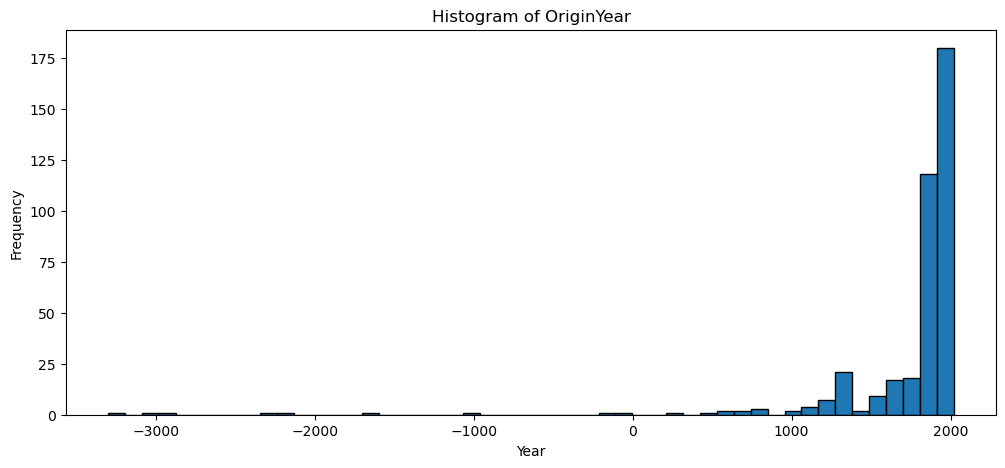

In [115]:
## histogram plot or originyear target
plt.figure(figsize=(12, 5))
plt.hist(game_df2['OriginYear'], bins=50, edgecolor='k')
plt.title('Histogram of OriginYear')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

In [116]:
## find out how many values are below 0
negative_count = (game_df2['OriginYear'] < 0).sum()
print("Number of OriginYear values less than 0:", negative_count)

Number of OriginYear values less than 0: 9


In [117]:
## create new df storing only values of originyear over 0
game_df4 = game_df2[game_df2['OriginYear'] >= 0].copy()
#game_df4 = game_df2.copy()

In [118]:
#create train test split for OriginYear model
X = game_df4.drop(columns= ["Category", "Region", "OriginYear", "BestAgent", "UCT"], axis=1)
OriginYear_Y = game_df4.OriginYear
X_trainval3, X_test3, y_trainval3, y_test3 = train_test_split(X, OriginYear_Y, random_state=42, test_size=0.2)
X_train3, X_val3, y_train3, y_val3 = train_test_split(X_trainval3, y_trainval3, random_state=42, test_size=0.25)

## mean impute missing values
X_train3[["AdvantageP1", "Balance", "Drawishness"]] = impmean.fit_transform(X_train3[["AdvantageP1", "Balance", "Drawishness"]] )
X_val3[["AdvantageP1", "Balance", "Drawishness"]] = impmean.transform(X_val3[["AdvantageP1", "Balance", "Drawishness"]] )
X_test3[["AdvantageP1", "Balance", "Drawishness"]] = impmean.transform(X_test3[["AdvantageP1", "Balance", "Drawishness"]] )

## most frequent impute missing values
X_train3[["Math"]] = impfreq.fit_transform(X_train3[["Math"]])
X_val3[["Math"]] = impfreq.transform(X_val3[["Math"]])
X_test3[["Math"]] = impfreq.transform(X_test3[["Math"]])

## initialise target independent scaler
scaler3 = StandardScaler()

## scale train and test for OriginYear
X_train3_scaled = scaler3.fit_transform(X_train3)
X_val3_scaled = scaler3.transform(X_val3)
X_test3_scaled = scaler3.transform(X_test3)



##### as there are 163 different types of years, rather than trying to guess the year exactly (classifier) we will try and get as close to the year as possible (regressor)


In [119]:
 #k nearest neighbors grid search for target category -- note used grid search instead of randomised as only 100 possible iterations.
print("\n------- K Nearest Neighbors -------")
rsknn = GridSearchCV(KNNR, gridKNN, cv=kfold5, scoring='neg_mean_squared_error', n_jobs=-1)
rsknn.fit(X_train3_scaled, y_train3)
print("Accuracy best parameters", rsknn.best_params_)
pred = rsknn.predict(X_val3_scaled)
rmse = np.sqrt(mean_squared_error(y_val3, pred))
print("Best RMSE on validation set:", rmse)

## linear Regression Model - no hyperparameters
print("\n------- Linear Regression -------")
LiR.fit(X_train3_scaled, y_train3)
pred = LiR.predict(X_val3_scaled)
rmse = np.sqrt(mean_squared_error(y_val3, pred))
print("Best RMSE on validation set:", rmse)

## Lasso regression model grid search
print("\n------- Lasso -------")
gslas = GridSearchCV(lasso, gridLas, cv=kfold5, scoring='neg_mean_squared_error', n_jobs=-1)
gslas.fit(X_train3_scaled, y_train3)
print("Model Best Parameters", gslas.best_params_)
pred = gslas.predict(X_val3_scaled)
rmse = np.sqrt(mean_squared_error(y_val3, pred))
print("Best RMSE on validation set:", rmse)

## Ridge regression model grid search
print("\n------- Ridge -------")
gsrid = GridSearchCV(ridge, gridRid, cv=kfold5, scoring='neg_mean_squared_error', n_jobs=-1)
gsrid.fit(X_train3_scaled, y_train3)
print("Model Best Parameters", gsrid.best_params_)
pred = gsrid.predict(X_val3_scaled)
rmse = np.sqrt(mean_squared_error(y_val3, pred))
print("Best RMSE on validation set:", rmse)

##elastic net regression model grid search
print("\n------- ElasticNet -------")
gsEN = GridSearchCV(elasticnet, gridEN, cv=kfold5, scoring='neg_mean_squared_error', n_jobs=-1)
gsEN.fit(X_train3_scaled, y_train3)
print("Model Best Parameters", gsEN.best_params_)
pred = gsEN.predict(X_val3_scaled)
rmse = np.sqrt(mean_squared_error(y_val3, pred))
print("Best RMSE on validation set:", rmse)

## decision tree regressor randmoised search
print("\n------- Decision Tree -------")
rs3 = RandomizedSearchCV(DTR, gridDTR, cv=kfold5, n_iter=200, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
rs3.fit(X_train3, y_train3)  # decision tree does not need scaling
print("Accuracy best parameters", rs3.best_params_)
pred = rs3.predict(X_val3)
rmse = np.sqrt(mean_squared_error(y_val3, pred))
print("Best RMSE on validation set:", rmse)

# random forest regressor randomised search
print("\n------- Random Forest -------")
rsrf3 = RandomizedSearchCV(RFR, gridRFR, cv=kfold5, n_iter=20, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
rsrf3.fit(X_train3, y_train3)  # random forest does not need scaling
print("Accuracy best parameters", rsrf3.best_params_)
pred = rsrf3.predict(X_val3)
rmse = np.sqrt(mean_squared_error(y_val3, pred))
print("Best RMSE on validation set:", rmse)

# xgboost regressor randomized search
print("\n------- XGBoost -------")
rsxg3 = RandomizedSearchCV(XGBR, gridXGB, cv=kfold5, n_iter=10, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
rsxg3.fit(X_train3_scaled, y_train3)
print("Accuracy Best Parameters", rsxg3.best_params_)
pred = rsxg3.predict(X_val3)
rmse = np.sqrt(mean_squared_error(y_val3, pred))
print("Best RMSE on validation set:", rmse)



------- K Nearest Neighbors -------
Accuracy best parameters {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Best RMSE on validation set: 330.27846475910917

------- Linear Regression -------
Best RMSE on validation set: 1891.248018059618

------- Lasso -------
Model Best Parameters {'alpha': 10}
Best RMSE on validation set: 332.3921312201294

------- Ridge -------
Model Best Parameters {'alpha': 100}
Best RMSE on validation set: 347.5042714458604

------- ElasticNet -------
Model Best Parameters {'alpha': 10, 'l1_ratio': 1}
Best RMSE on validation set: 332.3921312201294

------- Decision Tree -------
Accuracy best parameters {'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': None, 'max_depth': 5, 'criterion': 'squared_error'}
Best RMSE on validation set: 326.91748869933514

------- Random Forest -------
Accuracy best parameters {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 22, 'criterion': 'ab

In [120]:
## create dictionary of "best" hyperparameters for models
models3 = {
    "KNN": KNeighborsRegressor(metric='manhattan', n_neighbors=7, weights='distance'),
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(alpha = 10),
    "Ridge" : Ridge(alpha = 100),
    "Elastic Net" : ElasticNet(alpha = 10, l1_ratio = 1),
    "Decision Tree": DecisionTreeRegressor(min_samples_split=20, min_samples_leaf=10, max_features=None, max_depth=5, criterion='squared_error', random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=500, min_samples_split=2, min_samples_leaf=1, max_features='log2', max_depth=22, criterion='absolute_error', random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=50, estimator = DTR, random_state=42)
}

## for loop to display varying scores for all models
for name, model in models3.items():
    # choose scaled or unscaled 
    if name in ["KNN", "Linear Regression", "Lasso", "Ridge", "Elastic Net"]:  
        model.fit(X_train3_scaled, y_train3)
        pred = model.predict(X_test3_scaled)
    else:
        model.fit(X_train3, y_train3)
        pred = model.predict(X_test3)
        
    mse = mean_squared_error(y_test3, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test3, pred)
    r2 = r2_score(y_test3, pred)


    print(f"\n------- {name} -------")
    print("R²:", r2)
    print("RMSE:", rmse)
    print("MAE:", mae)

## xg boost scores
print("\n------- XGBoost -------")
xgbc3 = xgb.XGBRegressor(subsample = 0.8, 
                            n_estimators = 500, 
                            min_child_weight = 3,
                            max_depth = 5, 
                            learning_rate=0.01,
                            gamma = 1.5,
                            colsample_bytree = 0.8,
                            random_state=42)
xgbc3.fit(X_train3_scaled, y_train3)

pred = xgbc3.predict(X_test3_scaled)
mse = mean_squared_error(y_test3, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test3, pred)
r2 = r2_score(y_test3, pred)
print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)



------- KNN -------
R²: 0.40638720340617684
RMSE: 213.0704086198328
MAE: 126.44234126356332

------- Linear Regression -------
R²: -70.57895042905396
RMSE: 2339.721546451329
MAE: 1576.819930140294

------- Lasso -------
R²: 0.006219608665942844
RMSE: 275.68727655488397
MAE: 157.5113226419318

------- Ridge -------
R²: 0.13901507786410006
RMSE: 256.60746391298915
MAE: 149.70414786012034

------- Elastic Net -------
R²: 0.006219608665942844
RMSE: 275.68727655488397
MAE: 157.5113226419318

------- Decision Tree -------
R²: 0.12335725781093732
RMSE: 258.93027482905296
MAE: 154.130010618313

------- Random Forest -------
R²: 0.46598363026492484
RMSE: 202.0918485980304
MAE: 123.68117948717953

------- AdaBoost -------
R²: 0.4544291129613298
RMSE: 204.26648004945616
MAE: 103.97435897435898

------- XGBoost -------
R²: 0.42049431800842285
RMSE: 210.52338980799735
MAE: 123.05706787109375


### Stacking Ensemble Model for all OriginYear Models

In [121]:
## initialise our final stack model or "meta learner"
stack_final_model = KNeighborsRegressor(metric='manhattan', n_neighbors=10, weights='distance')

best_models3 = [
    ('knn3', KNeighborsRegressor(metric='manhattan', n_neighbors=7, weights='distance')),
    ('elasticnet', ElasticNet(alpha = 10, l1_ratio = 1)),
    ('rfr3', RandomForestRegressor(n_estimators=500, min_samples_split=2, min_samples_leaf=1, max_features='log2', max_depth=22, criterion='absolute_error', random_state=42)),
    ('adb3', AdaBoostRegressor(n_estimators=50, estimator = DTR, random_state=42)),
    ('xgb3', xgbc3)
]
    

## create the stack containing all our best models
stack3 = StackingRegressor( estimators = best_models3,
    final_estimator = stack_final_model,
    cv = kfold5
)

## fit the stack to the training data
stack3.fit(X_train3_scaled, y_train3)
pred = stack3.predict(X_test3_scaled)


pred = stack3.predict(X_test3_scaled)
mse = mean_squared_error(y_test3, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test3, pred)
r2 = r2_score(y_test3, pred)
print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R²: 0.45312547908331424
RMSE: 204.5103803622831
MAE: 116.81644292758585


##### Dummy Regressor for testing

In [122]:
## initialise dummy regressor with mean strategy, fit it to training data and test against our holdout test
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train3_scaled, y_train3)
pred = dummy.predict(X_test3_scaled)
mse = mean_squared_error(y_test3, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test3, pred)
r2 = r2_score(y_test3, pred)
print("-------- Dummy ------")
print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

-------- Dummy ------
R²: -0.00700663693773218
RMSE: 277.5157768614478
MAE: 183.47569097569098


# BestAgent

In [123]:
## get count of all the best agents in target 
bestagent_counts = game_df["BestAgent"].value_counts()
print(bestagent_counts)

BestAgent
Alpha-Beta             229
MAST                    57
UCT                     51
Progressive History     37
Random                  12
MC-GRAVE                10
Name: count, dtype: int64


In [124]:
## train test validation splits
X = game_df2.drop(columns= ["Category", "Region", "OriginYear", "BestAgent", "UCT"], axis=1)
BestAgent_Y = game_df2.BestAgent
X_trainval4, X_test4, y_trainval4, y_test4 = train_test_split(X, BestAgent_Y, random_state=42, test_size=0.2, stratify=BestAgent_Y)
X_train4, X_val4, y_train4, y_val4 = train_test_split(X_trainval4, y_trainval4, random_state=42, test_size=0.25, stratify=y_trainval4)

##impute mean for best agent 
X_train4[["AdvantageP1", "Balance", "Drawishness"]] = impmean.fit_transform(X_train4[["AdvantageP1", "Balance", "Drawishness"]] )
X_val4[["AdvantageP1", "Balance", "Drawishness"]] = impmean.transform(X_val4[["AdvantageP1", "Balance", "Drawishness"]] )
X_test4[["AdvantageP1", "Balance", "Drawishness"]] = impmean.transform(X_test4[["AdvantageP1", "Balance", "Drawishness"]] )

## impute most frequent for best agent
X_train4[["Math"]] = impfreq.fit_transform(X_train4[["Math"]])
X_val4[["Math"]] = impfreq.transform(X_val4[["Math"]])
X_test4[["Math"]] = impfreq.transform(X_test4[["Math"]])

##initialise target independent scaler
scaler4 = StandardScaler()

## scale train and test for BestAgent
X_train4_scaled = scaler4.fit_transform(X_train4)
X_val4_scaled = scaler4.transform(X_val4)
X_test4_scaled = scaler4.transform(X_test4)

In [125]:
# KNN
rsknn4 = GridSearchCV(KNNC, gridKNN, cv=skfold5, scoring='balanced_accuracy', n_jobs=-1)
rsknn4.fit(X_train4_scaled, y_train4)
print(f"------- K Nearest Neighbors -------")
print("Best parameters:", rsknn4.best_params_)
pred = rsknn4.predict(X_val4_scaled)
print("Balanced accuracy on validation set:", balanced_accuracy_score(y_val4, pred))

# Logistic Regression
LoR4 = LogisticRegression(class_weight='balanced', random_state=42)
rslor4 = GridSearchCV(LoR4, gridLor, cv=skfold5, scoring='balanced_accuracy', n_jobs=-1)
rslor4.fit(X_train4_scaled, y_train4)
print("\n------- Logistic Regression -------")
print("Best parameters:", rslor4.best_params_)
pred = rslor4.predict(X_val4_scaled)
print("Balanced accuracy on validation set:", balanced_accuracy_score(y_val4, pred))

# Decision Tree
print("\n------- Decision Tree -------")
rsdt4 = RandomizedSearchCV(DTC, gridDTC, cv=skfold5, n_iter=800, scoring='balanced_accuracy', n_jobs=-1, random_state=42)
rsdt4.fit(X_train4, y_train4)
print("Best parameters:", rsdt4.best_params_)
pred = rsdt4.predict(X_val4)
print("Balanced accuracy on validation set:", balanced_accuracy_score(y_val4, pred))

# Random Forest
print("\n------- Random Forest -------")
rsrf4 = RandomizedSearchCV(RFC, gridRFC, cv=skfold5, n_iter=20, scoring='balanced_accuracy', n_jobs=-1, random_state=42)
rsrf4.fit(X_train4, y_train4)
print("Best parameters:", rsrf4.best_params_)
pred = rsrf4.predict(X_val4)
print("Balanced accuracy on validation set:", balanced_accuracy_score(y_val4, pred))

# XGBoost (with encoded targets)
le4 = LabelEncoder()
y_trainval4_enc = le4.fit_transform(y_trainval4)
y_train4_enc = le4.transform(y_train4)
y_val4_enc = le4.transform(y_val4)
y_test4_enc = le4.transform(y_test4)

print("\n------- XGBoost -------")
rsxg4 = RandomizedSearchCV(XGBC, gridXGB, cv=skfold5, n_iter=15, scoring='balanced_accuracy', n_jobs=-1, random_state=42)
rsxg4.fit(X_train4_scaled, y_train4_enc)
print("Best parameters:", rsxg4.best_params_)
pred = rsxg4.predict(X_val4_scaled)
print("Balanced accuracy on validation set:", balanced_accuracy_score(y_val4_enc, pred))

C:\Users\thoma\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.26368607 0.26368607 0.25217813 0.26368607 0.27793651 0.2789418
 0.26700176 0.29450617 0.27717813 0.29887125 0.26324515 0.29089065
 0.24604938 0.27422399 0.25010582 0.25922399 0.23992063 0.26495591
 0.2463933  0.27011464 0.27986772 0.27986772 0.27919753 0.27986772
 0.25606702 0.29075838 0.25888889 0.29446208 0.26747795 0.27929453
 0.26082011 0.28577601 0.2342769  0.2810582  0.25222222 0.28978836
 0.25455908 0.27272487 0.23603175 0.28855379        nan 0.28308642
        nan 0.28308642        nan 0.25089947        nan 0.28379189
        nan 0.2821164         nan 0.28687831        nan 0.27545855
        nan 0.27280423        nan 0.2783157         nan 0.27324515
 0.26368607 0.26368607 0.25217813 0.26368607 0.27793651 0.2789418
 0.26700176 0.29450617 0.27717813 0.29887125 0.26324515 0.29089065
 0.24604938 0.27422399 0.25010582 0.25922399 0.239920

------- K Nearest Neighbors -------
Best parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Balanced accuracy on validation set: 0.3016280820628647

------- Logistic Regression -------
Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Balanced accuracy on validation set: 0.46060919756571933

------- Decision Tree -------
Best parameters: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 22, 'criterion': 'entropy'}
Balanced accuracy on validation set: 0.48317648535039837

------- Random Forest -------
Best parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 19, 'criterion': 'gini'}
Balanced accuracy on validation set: 0.27268021833239225

------- XGBoost -------
Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0.5, 'colsample_bytree': 1.0}
Balanced accuracy on validation s

In [126]:
## create dictionary for "best" hyperparameter models
models4 = {
    "KNN": KNeighborsClassifier(metric='euclidean', n_neighbors=5, weights='distance'),
    "Logistic Regression": LogisticRegression(C=0.01, penalty='l2', solver='lbfgs'),
    "Decision Tree": DecisionTreeClassifier(min_samples_split=2, min_samples_leaf=1, max_features='sqrt', max_depth=22, criterion='entropy', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=500, min_samples_split=2, min_samples_leaf=2, max_features=None, max_depth=19, criterion='gini', random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, estimator = DTC, random_state=42)
}

## for loop for displaying different scoring metrics
for name, model in models4.items():
    # choose scaled or unscaled 
    if name in ["KNN", "Logistic Regression"]:  
        model.fit(X_train4_scaled, y_train4)
        pred = model.predict(X_test4_scaled)
        acc = model.score(X_test4_scaled, y_test4)
    else:
        model.fit(X_train4, y_train4)
        pred = model.predict(X_test4)
        acc = model.score(X_test4, y_test4)

    print(f"\n------- {name} -------")
    print("Accuracy:", acc)
    print("Balanced accuracy score on holdout test set", balanced_accuracy_score(y_test4, pred))
    print("Precision score on holdout test set", precision_score(y_test4, pred, average='weighted', zero_division=0))
    print("Recall Score score on holdout test set", recall_score(y_test4, pred, average='weighted'))
    print("F1 Score score on holdout test set", f1_score(y_test4, pred, average='weighted'))

## display xgboost score
print("\n------- XGBoost -------")
xgbc4 = xgb.XGBClassifier(subsample = 0.8, 
                            n_estimators = 200, 
                            min_child_weight = 1,
                            max_depth = 3, 
                            learning_rate=0.2,
                            gamma = 0.5,
                            colsample_bytree = 1,
                            random_state=42)
xgbc4.fit(X_train4_scaled, y_train4_enc)
print("Accuracy score on holdout test set", xgbc4.score(X_test4_scaled, y_test4_enc))
pred = xgbc4.predict(X_test4_scaled)
## compare results amongst 4 different scoring categories
print("Balanced accuracy score on holdout test set", balanced_accuracy_score(y_test4_enc, pred))
print("Precision score on holdout test set", precision_score(y_test4_enc, pred, average = 'weighted', zero_division=0))
print("Recall Accuracy score on holdout test set", recall_score(y_test4_enc, pred, average = 'weighted'))
print("F1 Accuracy score on holdout test set", f1_score(y_test4_enc, pred, average = 'weighted'))



------- KNN -------
Accuracy: 0.55
Balanced accuracy score on holdout test set 0.20326086956521738
Precision score on holdout test set 0.4618421052631579
Recall Score score on holdout test set 0.55
F1 Score score on holdout test set 0.4997269417475728

------- Logistic Regression -------
Accuracy: 0.5375
Balanced accuracy score on holdout test set 0.20241545893719806
Precision score on holdout test set 0.45508474576271185
Recall Score score on holdout test set 0.5375
F1 Score score on holdout test set 0.48547619047619045

------- Decision Tree -------
Accuracy: 0.5625
Balanced accuracy score on holdout test set 0.3401570048309179
Precision score on holdout test set 0.544911100803958
Recall Score score on holdout test set 0.5625
F1 Score score on holdout test set 0.5511550196561638

------- Random Forest -------
Accuracy: 0.65
Balanced accuracy score on holdout test set 0.3655193236714976
Precision score on holdout test set 0.5999621212121211
Recall Score score on holdout test set 0.65

##### Stacking Ensemble Model

In [127]:
## initialise our final stack model
stack_final_model4 = LogisticRegression(max_iter=1000)

best_models4 = [
    ('knn4', KNeighborsClassifier(metric='euclidean', n_neighbors=5, weights='distance')),
    ('logr4', LogisticRegression(C=0.01, penalty='l2', solver='lbfgs', max_iter=800)),
    ('rf4', RandomForestClassifier(n_estimators=500, min_samples_split=2, min_samples_leaf=2, max_features=None, max_depth=19, criterion='gini', random_state=42)),
    ('adb4', AdaBoostClassifier(n_estimators=50, estimator = DTC, random_state=42)),
    ('xgbc4', xgbc4)
]
    
## create the stack containing all our best models
stack4 = StackingClassifier( estimators = best_models4,
    final_estimator = stack_final_model4,
    cv = skfold5
)

## fit the stack to the training data
stack4.fit(X_train4_scaled, y_train4)
pred = stack4.predict(X_test4_scaled)

##
print("Accuracy score for Stack Model ", accuracy_score(y_test4, pred))
print("Balanced Accuracy score for Stack Model ", balanced_accuracy_score(y_test4, pred))
print("Precision score for Stack Model ", precision_score(y_test4, pred, average='weighted', zero_division=0))
print("Recall score for Stack Model ", recall_score(y_test4, pred, average='weighted'))
print("F1 Score score for Stack Model ", f1_score(y_test4, pred, average='weighted'))

Accuracy score for Stack Model  0.5625
Balanced Accuracy score for Stack Model  0.20966183574879227
Precision score for Stack Model  0.45751466275659824
Recall score for Stack Model  0.5625
F1 Score score for Stack Model  0.4959943639291466


##### Dummy Classifier, see how it compares

In [128]:
## initialise dummy classifier for most frequent, fit to training data and test on holdout test set
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train4_scaled, y_train4)
print("--------- Dummy ----------")
print("Dummy Accuracy score on holdout test set", dummy.score(X_test4_scaled, y_test4))
pred = dummy.predict(X_test4_scaled)
## compare results amongst 4 different scoring categories
print("Balanced accuracy score on holdout test set", balanced_accuracy_score(y_test4, pred))
print("Precision score on holdout test set", precision_score(y_test4, pred, average = 'weighted', zero_division=0))
print("Recall Accuracy score on holdout test set", recall_score(y_test4, pred, average = 'weighted'))
print("F1 Accuracy score on holdout test set", f1_score(y_test4, pred, average = 'weighted'))

--------- Dummy ----------
Dummy Accuracy score on holdout test set 0.575
Balanced accuracy score on holdout test set 0.16666666666666666
Precision score on holdout test set 0.330625
Recall Accuracy score on holdout test set 0.575
F1 Accuracy score on holdout test set 0.41984126984126985


# UCT

In [129]:
## display most common UCT
uct_counts = game_df2["UCT"].value_counts()
print(uct_counts.head(n=50))

UCT
50.0    19
60.0    14
64.0    11
46.5     9
69.0     8
53.0     8
70.0     8
61.0     8
65.0     7
59.0     7
55.0     7
47.5     7
48.0     7
43.0     6
59.5     6
45.0     6
66.0     6
71.0     6
53.5     6
54.0     6
58.0     6
47.0     6
36.5     5
41.0     5
72.0     5
55.5     5
49.0     5
39.5     5
40.0     5
38.0     4
37.5     4
75.5     4
54.5     4
68.0     4
75.0     4
44.5     4
74.0     4
44.0     4
51.0     4
42.5     4
62.0     4
73.0     4
34.5     3
63.5     3
56.0     3
67.0     3
63.0     3
38.5     3
52.0     3
69.5     3
Name: count, dtype: int64


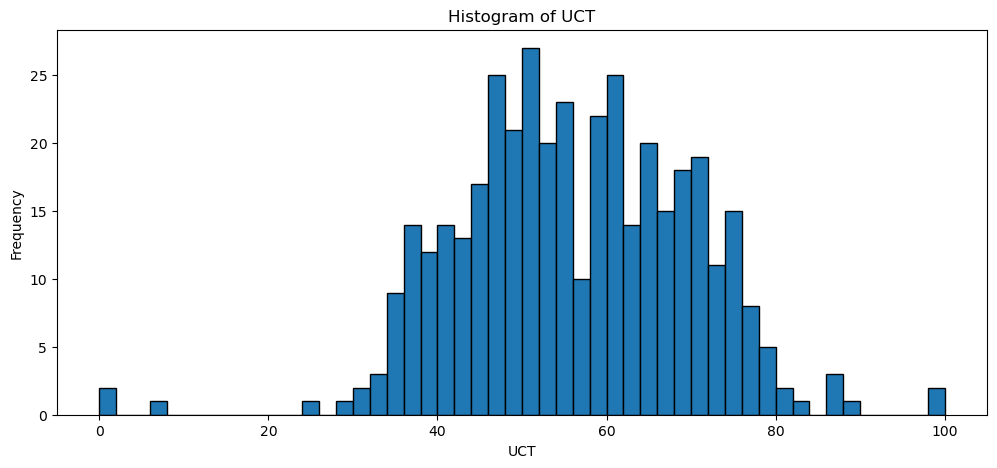

In [130]:
## display histogram
plt.figure(figsize=(12, 5))
plt.hist(game_df2['UCT'], bins=50, edgecolor='k')
plt.title('Histogram of UCT')
plt.xlabel('UCT')
plt.ylabel('Frequency')
plt.show()

In [131]:
##create train test split for UCT model
UCT_Y = game_df2.UCT
X_trainval5, X_test5, y_trainval5, y_test5 = train_test_split(X, UCT_Y, random_state=42, test_size=0.2)
X_train5, X_val5, y_train5, y_val5 = train_test_split(X_trainval5, y_trainval5, random_state=42, test_size=0.25)

## impute mean for UCT
X_train5[["AdvantageP1", "Balance", "Drawishness"]] = impmean.fit_transform(X_train5[["AdvantageP1", "Balance", "Drawishness"]] )
X_val5[["AdvantageP1", "Balance", "Drawishness"]] = impmean.transform(X_val5[["AdvantageP1", "Balance", "Drawishness"]] )
X_test5[["AdvantageP1", "Balance", "Drawishness"]] = impmean.transform(X_test5[["AdvantageP1", "Balance", "Drawishness"]] )

## impute most frequent for UCT
X_train5[["Math"]] = impfreq.fit_transform(X_train5[["Math"]])
X_val5[["Math"]] = impfreq.transform(X_val5[["Math"]])
X_test5[["Math"]] = impfreq.transform(X_test5[["Math"]])

##initialise target independent scaler
scaler5 = StandardScaler()

## scale train and test for UCT
X_train5_scaled = scaler5.fit_transform(X_train5)
X_val5_scaled = scaler5.transform(X_val5)
X_test5_scaled = scaler5.transform(X_test5)

In [132]:
 #k nearest neighbors grid search for target category -- note used grid search instead of randomised as only 100 possible iterations.
print("\n------- K Nearest Neighbors -------")
rsknn5 = GridSearchCV(KNNR, gridKNN, cv=kfold5, scoring='neg_mean_squared_error', n_jobs=-1)
rsknn5.fit(X_train5_scaled, y_train5)
print("Accuracy best parameters", rsknn5.best_params_)
pred = rsknn5.predict(X_val5_scaled)
rmse = np.sqrt(mean_squared_error(y_val5, pred))
print("Best RMSE on validation set:", rmse)

print("\n------- Linear Regression -------")
LiR5 = LinearRegression()
LiR5.fit(X_train5_scaled, y_train5)
pred = LiR5.predict(X_val5_scaled)
rmse = np.sqrt(mean_squared_error(y_val5, pred))
print("Best RMSE on validation set:", rmse)


------- K Nearest Neighbors -------
Accuracy best parameters {'metric': 'cosine', 'n_neighbors': 9, 'weights': 'distance'}
Best RMSE on validation set: 14.676055911205328

------- Linear Regression -------
Best RMSE on validation set: 99.11759609869671


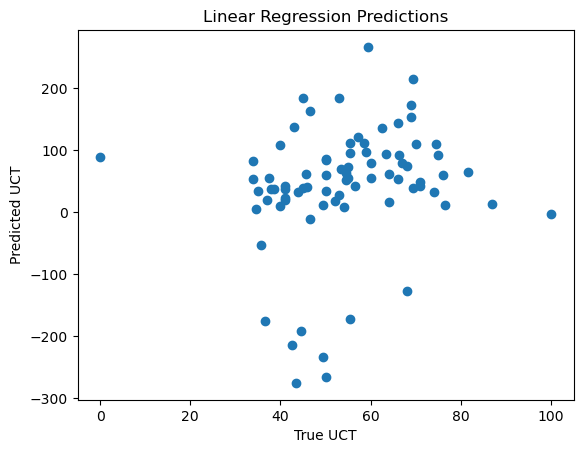

In [133]:
## linear regression score is very bad, lets see what the scatter plot looks like
import matplotlib.pyplot as plt
plt.scatter(y_val5, pred)
plt.xlabel("True UCT")
plt.ylabel("Predicted UCT")
plt.title("Linear Regression Predictions")
plt.show()

##### Linear Regression model is extremely poor and is predicting some values at almost -300, lets clip the predictions to be between 0,100

In [134]:
## clip linear regression results to be within 0 and 100
print("\n------- Linear Regression -------")
pred = np.clip(pred, 0, 100)
rmse = np.sqrt(mean_squared_error(y_val5, pred))
print("Best RMSE on validation set:", rmse)


------- Linear Regression -------
Best RMSE on validation set: 36.829144103056784


##### better result but still not great

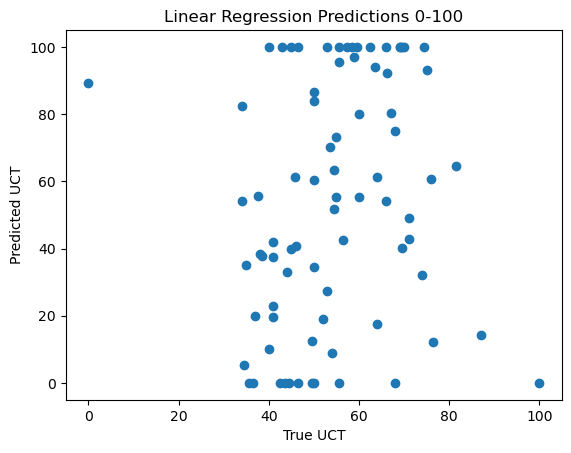

In [135]:
## lets see what the new scatter plot looks like
plt.scatter(y_val5, pred)
plt.xlabel("True UCT")
plt.ylabel("Predicted UCT")
plt.title("Linear Regression Predictions 0-100")
plt.show()

In [136]:
## lasso grid search for UCT
print("\n------- Lasso -------")
gslas5 = GridSearchCV(lasso, gridLas, cv=kfold5, scoring='neg_mean_squared_error', n_jobs=-1)
gslas5.fit(X_train5_scaled, y_train5)
print("Model Best Parameters", gslas5.best_params_)
pred = gslas5.predict(X_val5_scaled)
rmse = np.sqrt(mean_squared_error(y_val5, pred))
print("Best RMSE on validation set:", rmse)

# ridge gris dearch for UCT
print("\n------- Ridge -------")
gsrid5 = GridSearchCV(ridge, gridRid, cv=kfold5, scoring='neg_mean_squared_error', n_jobs=-1)
gsrid5.fit(X_train5_scaled, y_train5)
print("Model Best Parameters", gsrid5.best_params_)
pred = gsrid5.predict(X_val5_scaled)
rmse = np.sqrt(mean_squared_error(y_val5, pred))
print("Best RMSE on validation set:", rmse)

## elastic net gris search 
print("\n------- ElasticNet -------")
gsEN5 = GridSearchCV(elasticnet, gridEN, cv=kfold5, scoring='neg_mean_squared_error', n_jobs=-1)
gsEN5.fit(X_train5_scaled, y_train5)
print("Model Best Parameters", gsEN5.best_params_)
pred = gsEN5.predict(X_val5_scaled)
rmse = np.sqrt(mean_squared_error(y_val5, pred))
print("Best RMSE on validation set:", rmse)

## DTR randomised grid search
print("\n------- Decision Tree -------")
rsdt5 = RandomizedSearchCV(DTR, gridDTR, cv=kfold5, n_iter=200, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
rsdt5.fit(X_train5, y_train5)  # decision tree does not need scaling
print("Accuracy best parameters", rsdt5.best_params_)
pred = rsdt5.predict(X_val5)
rmse = np.sqrt(mean_squared_error(y_val5, pred))
print("Best RMSE on validation set:", rmse)

## RF randomized grid search
print("\n------- Random Forest -------")
rsrf5 = RandomizedSearchCV(RFR, gridRFR, cv=kfold5, n_iter=10, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
rsrf5.fit(X_train5, y_train5)  # random forest does not need scaling
print("Accuracy best parameters", rsrf5.best_params_)
pred = rsrf5.predict(X_val5)
rmse = np.sqrt(mean_squared_error(y_val5, pred))
print("Best RMSE on validation set:", rmse)

## xgboost grid search
print("\n------- XGBoost -------")
rsxg5 = RandomizedSearchCV(XGBR, gridXGB, cv=kfold5, n_iter=10, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
rsxg5.fit(X_train5_scaled, y_train5)
print("Accuracy Best Parameters", rsxg5.best_params_)
pred = rsxg5.predict(X_val5)
rmse = np.sqrt(mean_squared_error(y_val5, pred))
print("Best RMSE on validation set:", rmse)


------- Lasso -------
Model Best Parameters {'alpha': 0.5}
Best RMSE on validation set: 15.599615125911283

------- Ridge -------
Model Best Parameters {'alpha': 100}
Best RMSE on validation set: 14.978182365855012

------- ElasticNet -------
Model Best Parameters {'alpha': 1, 'l1_ratio': 0.5}
Best RMSE on validation set: 14.374611090237991

------- Decision Tree -------
Accuracy best parameters {'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': None, 'max_depth': 5, 'criterion': 'squared_error'}
Best RMSE on validation set: 13.32496858550264

------- Random Forest -------
Accuracy best parameters {'n_estimators': 200, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 45, 'criterion': 'absolute_error'}
Best RMSE on validation set: 12.29943740578946

------- XGBoost -------
Accuracy Best Parameters {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 1.5, 'colsample_bytree': 0.8}


In [137]:
## create dictionary of best performing hyperparameters
models5 = {
    "KNN": KNeighborsRegressor(metric='cosine', n_neighbors=10, weights='distance'),
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(alpha = 0.5),
    "Ridge" : Ridge(alpha = 100),
    "Elastic Net" : ElasticNet(alpha = 1, l1_ratio = 0.5),
    "Decision Tree": DecisionTreeRegressor(min_samples_split=20, min_samples_leaf=10, max_features=None, max_depth=5, criterion='squared_error', random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, min_samples_split=4, min_samples_leaf=1, max_features='log2', max_depth=45, criterion='absolute_error', random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=50, estimator = DTR, random_state=42)
}

## for loop to display results
for name, model in models5.items():
    # choose scaled or unscaled 
    if name in ["KNN", "Lasso", "Ridge", "Elastic Net"]:  
        model.fit(X_train5_scaled, y_train5)
        pred = model.predict(X_test5_scaled)
    elif name in ["Linear Regression"]:
        model.fit(X_train5_scaled, y_train5)
        pred = model.predict(X_test5_scaled)
        pred = np.clip(pred, 0, 100)
    else:
        model.fit(X_train5, y_train5)
        pred = model.predict(X_test5)
        
    mse = mean_squared_error(y_test5, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test5, pred)
    r2 = r2_score(y_test5, pred)

    print(f"\n------- {name} -------")
    print("R²:", r2)
    print("RMSE:", rmse)
    print("MAE:", mae)

## display xgboost results
print("\n------- XGBoost -------")
xgbc5 = xgb.XGBRegressor(subsample = 0.8, 
                            n_estimators = 500, 
                            min_child_weight = 3,
                            max_depth = 5, 
                            learning_rate=0.01,
                            gamma = 1.5,
                            colsample_bytree = 0.8,
                            random_state=42)
xgbc5.fit(X_train5_scaled, y_train5)

pred = xgbc5.predict(X_test5_scaled)
mse = mean_squared_error(y_test5, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test5, pred)
r2 = r2_score(y_test5, pred)
print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)


------- KNN -------
R²: 0.1891780199701527
RMSE: 11.937444807274886
MAE: 8.705478599325193

------- Linear Regression -------
R²: -7.484919975863715
RMSE: 38.61646322154881
MAE: 32.351226394739776

------- Lasso -------
R²: 0.22463369115007514
RMSE: 11.673526757726924
MAE: 8.477444032102323

------- Ridge -------
R²: 0.18222378086412372
RMSE: 11.988527908575996
MAE: 8.328890906703297

------- Elastic Net -------
R²: 0.21915843522335354
RMSE: 11.714670606404697
MAE: 8.518279590231316

------- Decision Tree -------
R²: 0.22291748718499416
RMSE: 11.686438770397679
MAE: 8.842332097014491

------- Random Forest -------
R²: 0.3732772799291185
RMSE: 10.49509416628757
MAE: 7.451285151831565

------- AdaBoost -------
R²: 0.3852950836642286
RMSE: 10.393982070469912
MAE: 7.371875

------- XGBoost -------
R²: 0.3297005628379792
RMSE: 10.85383080791144
MAE: 7.0500537872314455


In [138]:
## initialise our final stack model
stack_final_model5 = Ridge(alpha=1)

best_models5 = [
    ('knn5', KNeighborsRegressor(metric='cosine', n_neighbors=9, weights='distance')),
    ('elasticnet5', ElasticNet(alpha = 1, l1_ratio = 1)),
    ('rf5', RandomForestRegressor(n_estimators=200, min_samples_split=4, min_samples_leaf=1, max_features='log2', max_depth=45, criterion='absolute_error', random_state=42)),
    ('adb5', AdaBoostRegressor(n_estimators=50, estimator = DTR, random_state=42)),
    ('xgb5', xgbc5)
]

## create the stack containing all our best models
stack5 = StackingRegressor( estimators = best_models5,
    final_estimator = stack_final_model5,
    cv = kfold5
)

## fit the stack to the training data
stack5.fit(X_train5_scaled, y_train5)

## get predictions and print results against holdout test
pred = stack5.predict(X_test5_scaled)
mse = mean_squared_error(y_test5, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test5, pred)
r2 = r2_score(y_test5, pred)
print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R²: 0.36589320769250055
RMSE: 10.55673993008852
MAE: 7.18393876454171


#### Dummy Regressor to Test

In [139]:
## initialise dummy regressor, fit to training data and test against holdout test set
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train5_scaled, y_train5)
pred = dummy.predict(X_test5_scaled)
mse = mean_squared_error(y_test5, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test5, pred)
r2 = r2_score(y_test5, pred)
print("-------- Dummy ------")
print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

-------- Dummy ------
R²: -0.02349577480426701
RMSE: 13.411941396861533
MAE: 10.88443205868671


# Best Models, Important Features and Predictions

In [140]:
## Category - Stack Model ## Computationally too long to show feature importance, displayed xgboost importance as it is still high performing
print("\n---- XGBoost Feature Importance - Category ----")
# use xgboost built in feature  to get importance values
importances1 = xgbc1.feature_importances_

# match with feature names
feature_importances1 = pd.Series(importances1, index=X.columns).sort_values(ascending=False)
print(feature_importances1.head(n=10))

##Region - Random Forest Model ## rfc2
print("\n---- Random Forest Feature Importance - Region ----")
rfc2 = RandomForestClassifier(n_estimators=100, 
                              min_samples_split=2, 
                              min_samples_leaf=1, 
                              max_features='sqrt', 
                              max_depth=14, 
                              criterion='log_loss', 
                              random_state=42).fit(X_train2, y_train2)

importances2 = rfc2.feature_importances_

# match with feature names
feature_importances2 = pd.Series(importances2, index=X.columns).sort_values(ascending=False)
print(feature_importances2.head(n=10))


##OriginYear - Random Forest Model ## rfr3
print("\n---- Random Forest Feature Importance - OriginYear ----")
rfr3 = RandomForestRegressor(n_estimators=500, 
                      min_samples_split=2, 
                      min_samples_leaf=1, 
                      max_features='log2', 
                      max_depth=22, 
                      criterion='absolute_error', 
                      random_state=42).fit(X_train3, y_train3)
importances3 = rfr3.feature_importances_

# match with feature names
feature_importances3 = pd.Series(importances3, index=X.columns).sort_values(ascending=False)
print(feature_importances3.head(n=10))


##BestAgent -- XGBoost Model ## xgbc4
print("\n---- Random Forest Feature Importance - BestAgent ----")
rfr4 = RandomForestClassifier(n_estimators=500, 
                              min_samples_split=2, 
                              min_samples_leaf=2, 
                              max_features=None, 
                              max_depth=19, 
                              criterion='gini', 
                              random_state=42).fit(X_train4, y_train4)
importances4 = rfr4.feature_importances_

# match with feature names
feature_importances4 = pd.Series(importances4, index=X.columns).sort_values(ascending=False)
print(feature_importances4.head(n=10))


print("\n---- AdaBoost Feature Importance - UCT ----")

##UCT -- AdaBoost Regressor Model ## adb5
adb5 = AdaBoostRegressor(n_estimators=50, estimator = DTR, random_state=42).fit(X_train5, y_train5)
importances5 = adb5.feature_importances_

# match with feature names
feature_importances5 = pd.Series(importances5, index=X.columns).sort_values(ascending=False)
print(feature_importances5.head(n=10))



---- XGBoost Feature Importance - Category ----
NoOwnPiecesWin                 0.101759
PieceCount                     0.069547
RemoveEffectFrequency          0.064231
Line                           0.064055
Asymmetric                     0.062782
Dice                           0.053051
MancalaBoard                   0.052139
TwoSitesMoves                  0.037408
Stochastic                     0.036756
ReplacementCaptureFrequency    0.020968
dtype: float32

---- Random Forest Feature Importance - Region ----
BoardSitesOccupiedAverage    0.016948
MovesPerSecond               0.016137
PieceNumberAverage           0.015276
BranchingFactorAverage       0.014422
PlayoutsPerSecond            0.014166
BoardCoverageDefault         0.013704
DecisionMoves                0.013211
AdvantageP1                  0.013177
DurationTurnsNotTimeouts     0.012992
NumDirections                0.012953
dtype: float64

---- Random Forest Feature Importance - OriginYear ----
MovesPerSecond            0.015

In [147]:
## read in game data predictions
pred_data = pd.read_csv("GameData_Predictions.csv")
pred_data2= pred_data.copy()

In [148]:
## drop appropriate columns and see if there are any missing values
pred_data = pred_data.drop(columns=["GameName", "OutcomeUniformity", "Play"])
missing = pred_data.isna().sum()
print(missing[missing > 0].sort_values(ascending=True))

Series([], dtype: int64)


In [149]:
## make sure we are using the same scaler
pred_scaled1 = scaler1.transform(pred_data)
pred_scaled2 = scaler2.transform(pred_data)
## dont need to scale for model 3,4 and 5 as using tree based models

In [151]:
## use stack to predict for Category
category_predictions = stack1.predict(pred_scaled1)

## region stack
region_predictions = stack2.predict(pred_scaled2)

## originyear random forest
originyear_predictions = rfr3.predict(pred_data)

## best agent xgboost
bestagent_predictions = rfr4.predict(pred_data)

##UCT adaboost
uct_predictions = adb5.predict(pred_data)

## display results in a nice table
results_df = pd.DataFrame({
    "GameName": pred_data2["GameName"],   # or whatever your name column is called
    "Category": category_predictions,
    "Region": region_predictions,
    "OriginYear": originyear_predictions,
    "BestAgent": bestagent_predictions,
    "UCT": uct_predictions
})

display(results_df)

,GameName,Category,Region,OriginYear,BestAgent,UCT
0,Juroku Musashi,Hunt,Southern Asia,1870.472,Alpha-Beta,50.500000
1,Shiva,Space,Western Africa,1897.257,Alpha-Beta,53.500000
2,Saxun,War,Southern Asia,1433.491,Alpha-Beta,39.500000
3,Oure Ngat,Sow,Southeastern Asia,1930.109,MAST,63.500000
4,Djara-Badakh,Space,Southern Asia,1909.383,Progressive History,69.000000
5,Bis Gutiya,War,Southern Asia,1918.886,Alpha-Beta,39.500000
6,Rimau-Rimau Two Tigers,Hunt,Southern Asia,1866.689,Alpha-Beta,48.500000
7,Yahoudieh,Race,Northern Europe,1900.290,UCT,58.000000
8,Nama,Race,Southern Asia,1727.274,Progressive History,50.233333
9,Triodi Chios,Space,Southern Asia,1897.574,Progressive History,68.500000
